- Links uteis:

1 - https://theairlab.org/alfa-dataset/ (contém informações sobre o status do vôo.)

# Explorando os dados


In [1]:
import pandas as pd
import glob
import os


In [2]:
path = '../data/01_raw/processed/carbonZ_2018-07-18-15-53-31_1_engine_failure'
all_files = glob.glob(os.path.join(path, "*.csv"))

dfs = []

for filename in all_files:
    # Pega o nome do arquivo sem a extensão para usar como prefixo
    # Ex: 'engine_status' ou 'battery'
    topic_name = os.path.basename(filename).replace('.csv', '')
    
    temp_df = pd.read_csv(filename)
    
    # Identifica colunas numéricas
    cols = temp_df.select_dtypes(include=['number']).columns.tolist()
    if '%time' not in cols:
        temp_df['%time'] = pd.to_numeric(temp_df['%time'])
        cols.append('%time')
    
    temp_df = temp_df[cols].sort_values('%time')

    # RENOMEIA as colunas (exceto o tempo) para evitar colisão
    # field.data vira engine_status_field.data
    new_names = {c: f"{topic_name}_{c}" for c in temp_df.columns if c != '%time'}
    temp_df.rename(columns=new_names, inplace=True)
    
    dfs.append(temp_df)



# Ordenar a lista de dfs pelo tamanho (o maior primeiro servirá de base)
dfs.sort(key=len, reverse=True)# 1. Primeiro, encontre o 'timestamp' inicial de todo o voo

# (O menor tempo entre todos os dataframes)
min_time = min([df['%time'].min() for df in dfs])

# 2. Normalize todos os dataframes para segundos relativos ao início
for df in dfs:
    df['%time'] = (df['%time'] - min_time) / 1e9

# Agora, o seu código de merge_asof funcionará perfeitamente com 
# o eixo X em segundos, facilitando a visualização e interpretação.
merged_df = dfs[0]

for next_df in dfs[1:]:
    cols_to_use = next_df.columns.difference(merged_df.columns).tolist()
    # Certifique-se de que '%time' esteja na lista para o merge_asof
    if '%time' not in cols_to_use:
        cols_to_use.append('%time')
    
    merged_df = pd.merge_asof(
        merged_df.sort_values('%time'), 
        next_df[cols_to_use].sort_values('%time'), 
        on='%time', 
        direction='nearest'
    )

print(f"Shape final do dataset: {merged_df.shape}")

In [3]:
import pandas as pd
import glob
import os

# 1. Encontrar o timestamp inicial absoluto de todos os arquivos antes de qualquer processamento
min_time = min([df['%time'].min() for df in dfs])

# 2. Normalizar o tempo e ordenar cada DataFrame individualmente
processed_dfs = []
for df in dfs:
    # Criar uma cópia para não alterar a lista original acidentalmente
    temp_df = df.copy()
    temp_df['%time'] = (temp_df['%time'] - min_time) / 1e9
    temp_df = temp_df.sort_values('%time')
    processed_dfs.append(temp_df)

# 3. Ordenar a lista pelo tamanho para garantir que o dataframe base seja o mais denso
processed_dfs.sort(key=len, reverse=True)

# 4. Inicializar o dataframe principal
merged_df = processed_dfs[0]

# 5. Realizar o join iterativo
for next_df in processed_dfs[1:]:
    # Identificar colunas que ainda não estão no merged_df
    cols_to_use = next_df.columns.difference(merged_df.columns).tolist()
    if '%time' not in cols_to_use:
        cols_to_use.append('%time')
    
    # merge_asof com direção 'backward' para garantir que NaNs apareçam 
    # se o sensor ainda não tiver começado a registrar naquele timestamp
    merged_df = pd.merge_asof(
        merged_df, 
        next_df[cols_to_use], 
        on='%time', 
        direction='backward'
    )

# 6. Preencher todos os valores ausentes com 0
# Isso afetará tanto o início (sensores atrasados) quanto falhas de log no meio
merged_df.fillna(0, inplace=True)

# 7. (Opcional) Converter colunas de status/inteiras que ficaram como float após o NaN
# merged_df = merged_df.infer_objects() 

print(f"Merge concluído!")
print(f"Shape final: {merged_df.shape}")
print(f"Eixo temporal: de {merged_df['%time'].min():.2f}s a {merged_df['%time'].max():.2f}s")

Merge concluído!
Shape final: (26183, 531)
Eixo temporal: de 0.04s a 132.39s


- Diferente de um join comum, o merge_asof com nearest é o mais indicado para sensores de drones por dois motivos:

- Latência de Sensores: O sensor de GPS pode registrar às 10.001s e o acelerômetro às 10.002s. O nearest garante que eles se alinhem no "momento" mais próximo.

- Preenchimento de NaNs: Se você usar left ou right puro, terá muitos buracos nos dados onde as frequências não batem.

In [4]:
print(merged_df.columns.tolist())

['%time', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavlink-from_field.header.seq', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavlink-from_field.header.stamp', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavlink-from_field.header.frame_id', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavlink-from_field.framing_status', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavlink-from_field.magic', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavlink-from_field.len', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavlink-from_field.incompat_flags', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavlink-from_field.compat_flags', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavlink-from_field.seq', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavlink-from_field.sysid', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavlink-from_field.compid', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavlink-from_field.msgid', 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavlink-from_field.check

In [5]:
columns_field_data = [col for col in merged_df.columns if 'field.data' in col]

In [6]:
columns_field_data

['carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-rel_alt_field.data',
 'carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-compass_hdg_field.data',
 'carbonZ_2018-07-18-15-53-31_1_engine_failure-failure_status-engines_field.data']

In [7]:
merged_df[columns_field_data]

,carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-rel_alt_field.data,carbonZ_2018-07-18-15-53-31_1_engine_failure-mavros-global_position-compass_hdg_field.data,carbonZ_2018-07-18-15-53-31_1_engine_failure-failure_status-engines_field.data
0,0.000,0.00,0.0
1,0.000,0.00,0.0
2,0.000,0.00,0.0
3,0.000,0.00,0.0
4,0.000,0.00,0.0
...,...,...,...
26178,28.329,283.02,1.0
26179,28.329,283.02,1.0
26180,28.329,283.02,1.0
26181,28.329,283.02,1.0


In [8]:
import matplotlib.pyplot as plt

def plot_flight_data_by_source(df, source_name, skip_noise=True):
    """
    df: DataFrame com o join completo
    source_name: String contida no nome das colunas (ex: 'battery' ou 'imu-data_raw')
    skip_noise: Se True, ignora colunas de covariância e metadados técnicos
    """
    # 1. Identificar colunas que pertencem a esta fonte
    # O padrão do join é: [NomeDoArquivo]_field.[Campo]
    cols = [c for c in df.columns if source_name in c and '_field.' in c]
    
    if skip_noise:
        noise_keywords = ['covariance', 'checksum', 'magic', 'seq', 'stamp', 'frame_id', 'sysid', 'compid', 'msgid']
        cols = [c for c in cols if not any(k in c.lower() for k in noise_keywords)]

    if not cols:
        print(f"Nenhuma coluna relevante encontrada para: {source_name}")
        return

    # 2. Configurar o layout dos gráficos
    n_cols = len(cols)
    fig, axes = plt.subplots(n_cols, 1, figsize=(15, 2.5 * n_cols), sharex=True)
    
    if n_cols == 1:
        axes = [axes]

    print(f"Plotando {n_cols} colunas de: {source_name}")
    
    # 3. Gerar os plots
    for i, col in enumerate(cols):
        clean_label = col.split('_field.')[-1] # Nome humano da variável
        axes[i].plot(df['%time'], df[col], label=clean_label, color='tab:blue')
        axes[i].set_ylabel(clean_label)
        axes[i].grid(True, alpha=0.3)
        axes[i].legend(loc='upper right')

    axes[-1].set_xlabel('Time (%time)')
    plt.suptitle(f"Análise de Sensores: {source_name}", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    
    # Salvar ou mostrar
    #plt.savefig(f"plot_{source_name.replace('-', '_')}.png")
    plt.show()

# --- Exemplo de Uso ---
# Para ver o que aconteceu com a bateria:
# plot_flight_data_by_source(merged_df, 'mavros-battery')

# Para ver o status do motor (onde você comentou que está o field.data):
# plot_flight_data_by_source(merged_df, 'engine_failure')

Fontes detectadas no merge:
 - diagnostics
 - failure_status-engines
 - mavctrl-path_dev
 - mavctrl-rpy
 - mavlink-from
 - mavros-battery
 - mavros-global_position-compass_hdg
 - mavros-global_position-global
 - mavros-global_position-local
 - mavros-global_position-raw-fix
 - mavros-global_position-raw-gps_vel
 - mavros-global_position-rel_alt
 - mavros-imu-atm_pressure
 - mavros-imu-data
 - mavros-imu-data_raw
 - mavros-imu-mag
 - mavros-imu-temperature
 - mavros-local_position-odom
 - mavros-local_position-pose
 - mavros-local_position-velocity
 - mavros-nav_info-airspeed
 - mavros-nav_info-errors
 - mavros-nav_info-pitch
 - mavros-nav_info-roll
 - mavros-nav_info-velocity
 - mavros-nav_info-yaw
 - mavros-rc-in
 - mavros-rc-out
 - mavros-setpoint_raw-local
 - mavros-setpoint_raw-target_global
 - mavros-state
 - mavros-time_reference
 - mavros-vfr_hud
 - mavros-wind_estimation
Plotando 12 colunas de: mavros-battery


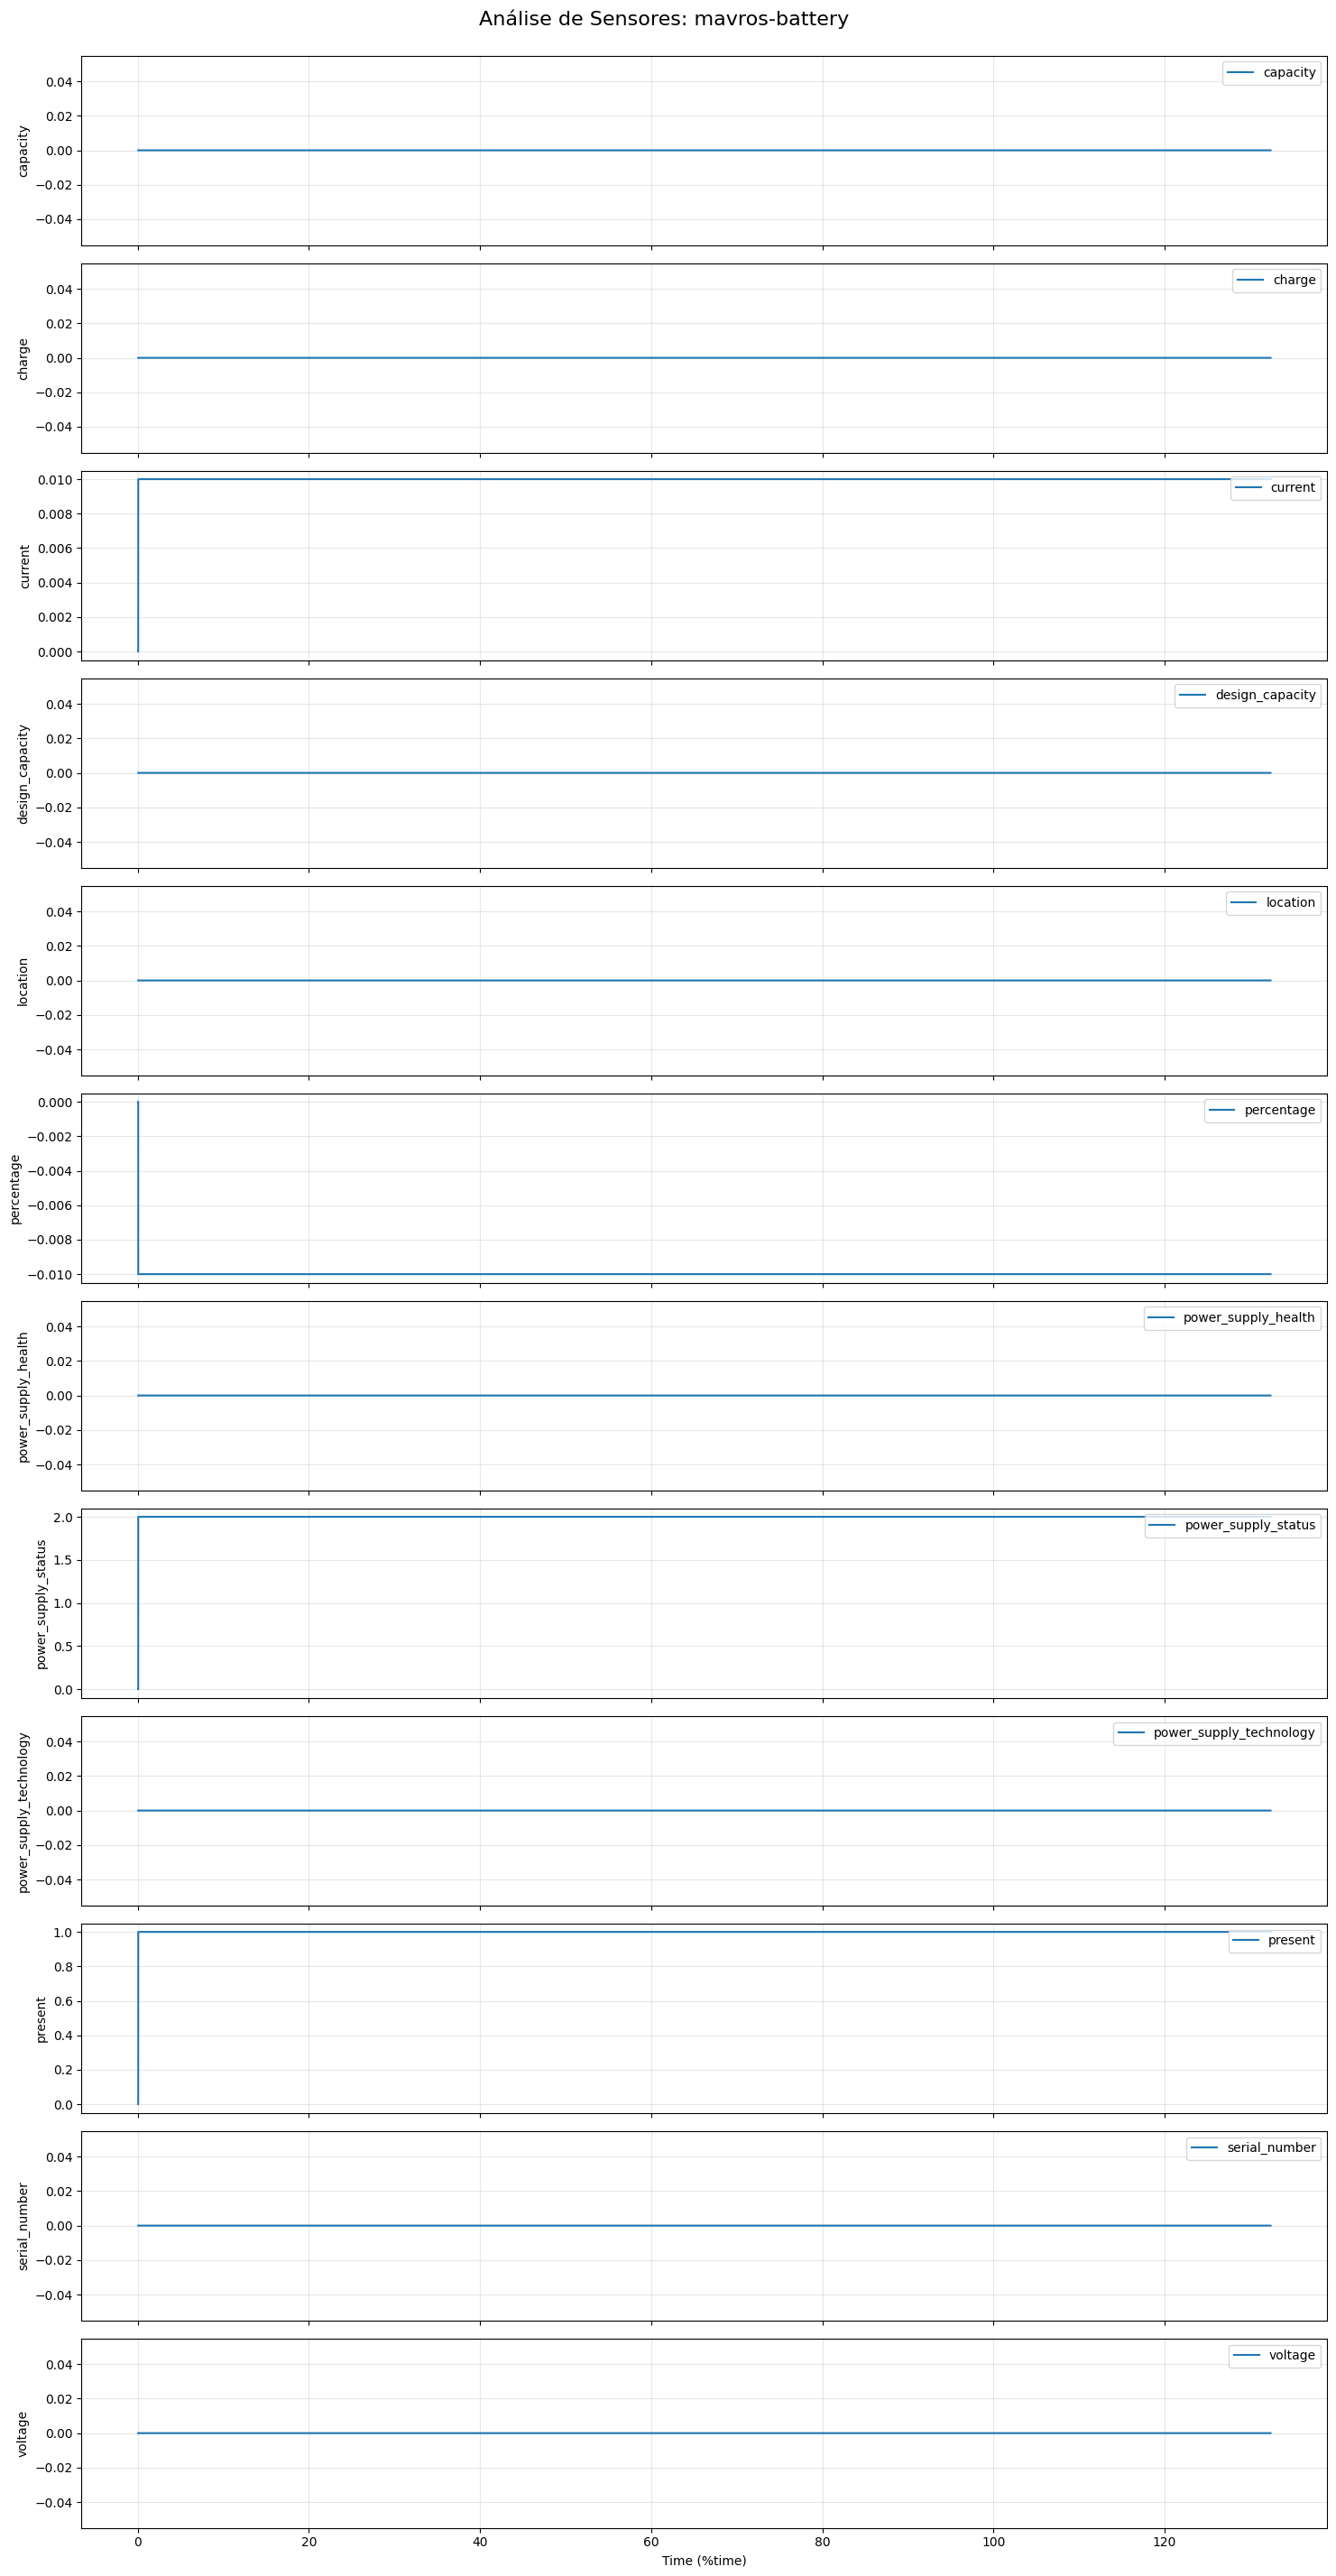

Plotando 2 colunas de: mavros-nav_info-airspeed


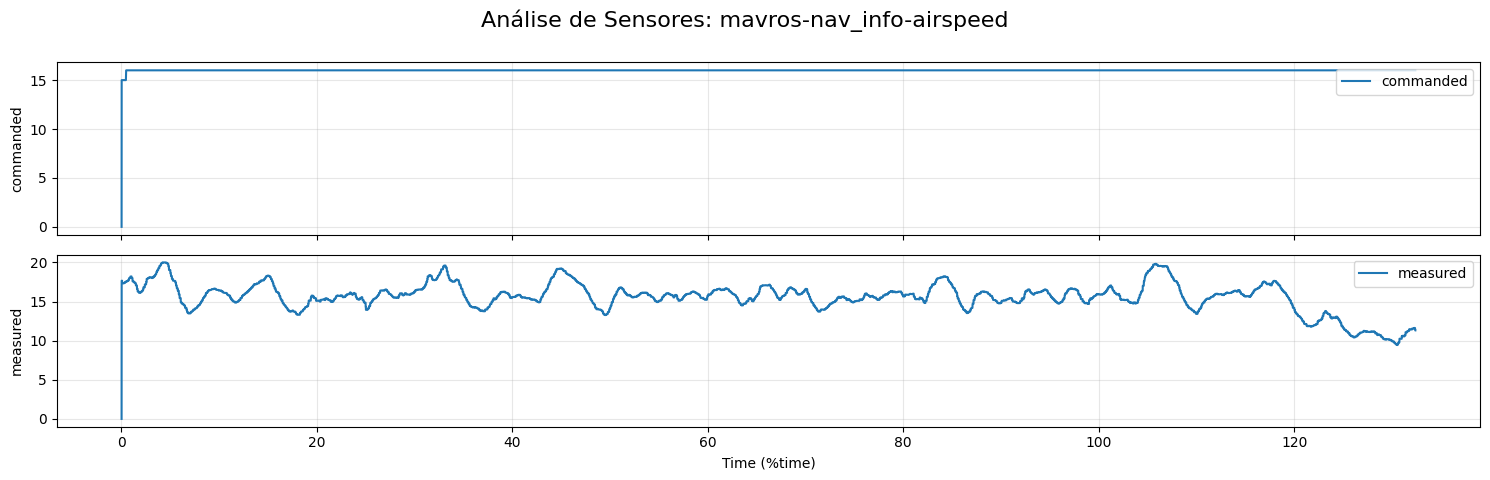

Plotando 10 colunas de: mavros-imu-data_raw


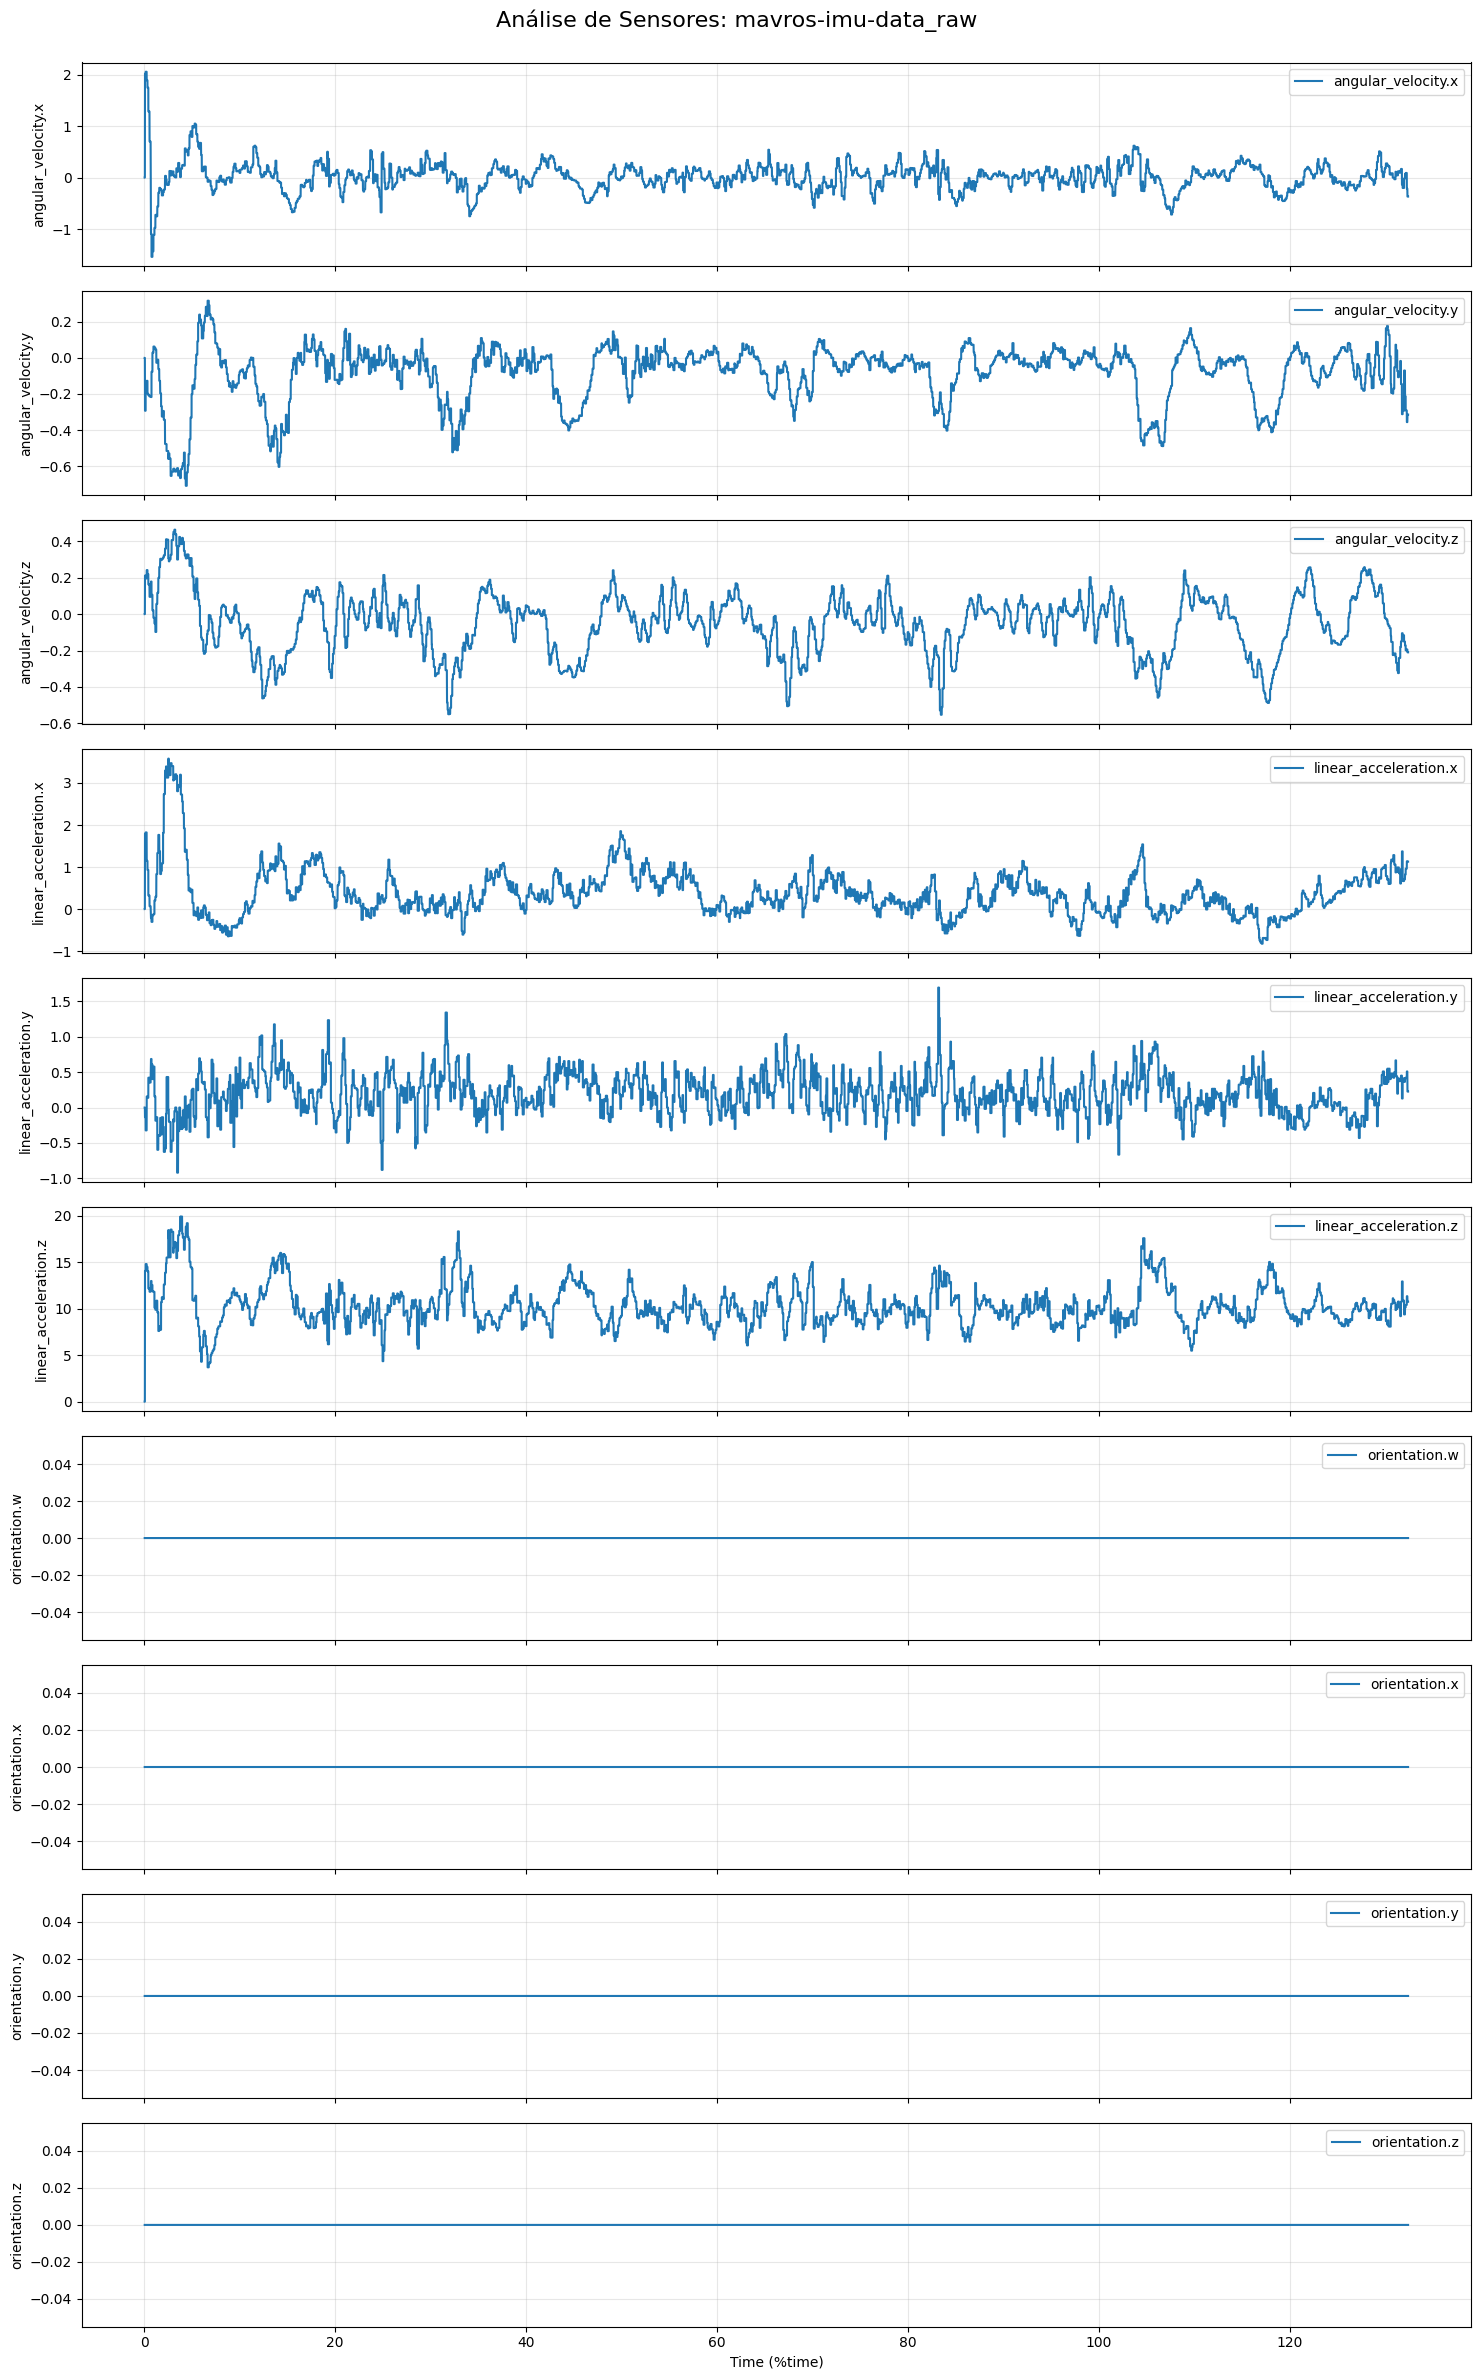

Plotando 3 colunas de: mavctrl-rpy


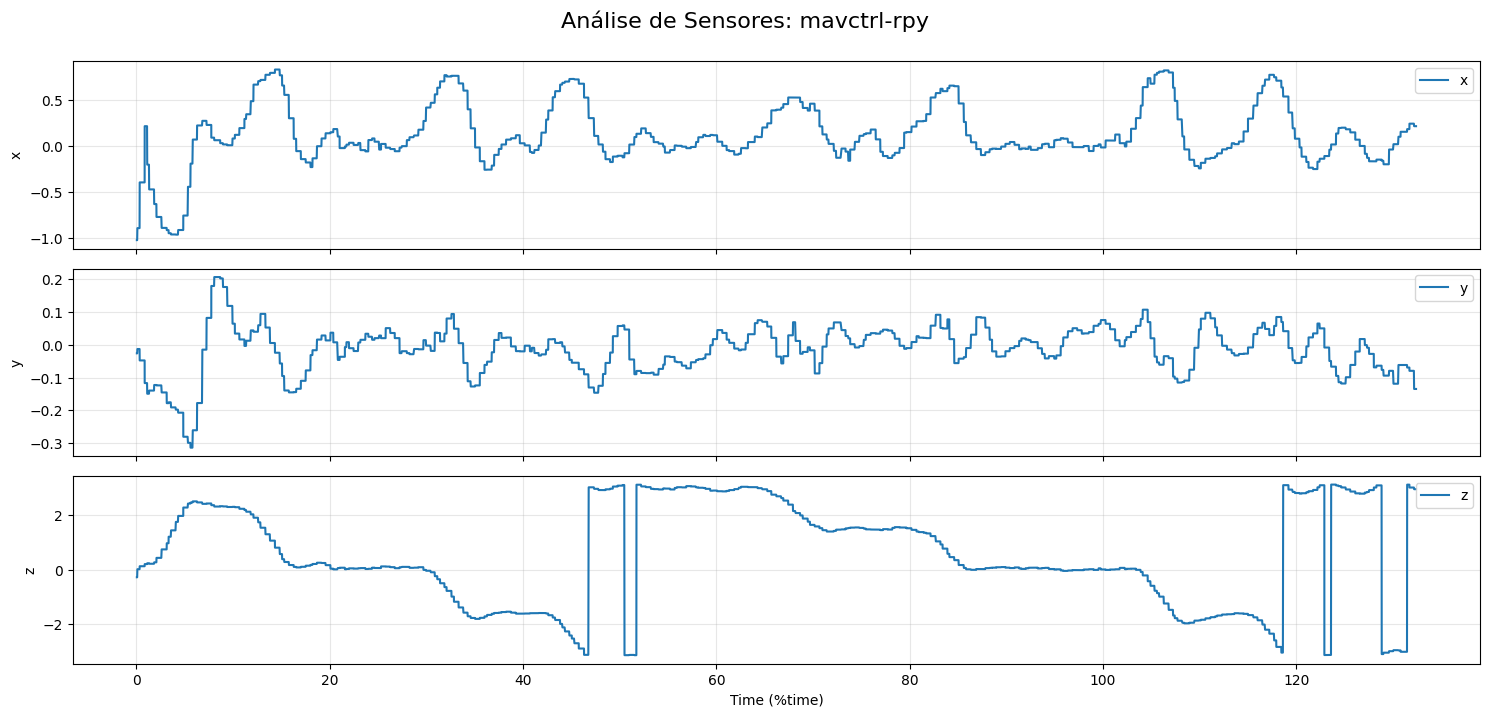

In [9]:
# Descobrir todas as fontes (arquivos originais) presentes no join
fontes = set([c.split('_field.')[0] for c in merged_df.columns if '_field.' in c])
print("Fontes detectadas no merge:")
for f in sorted(fontes):
    # Exibe apenas a parte final do nome para facilitar a leitura
    print(f" - {f.split('engine_failure-')[-1]}")

# Sugestão de exploração rápida:
interessantes = ['mavros-battery', 'mavros-nav_info-airspeed', 'mavros-imu-data_raw', 'mavctrl-rpy']
for p in interessantes:
    plot_flight_data_by_source(merged_df, p)

## Fontes que ainda restam explorar no merge:
 - diagnostics
 - failure_status-engines
 - mavctrl-path_dev
 - mavlink-from
 - mavros-global_position-compass_hdg
 - mavros-global_position-global
 - mavros-global_position-local
 - mavros-global_position-raw-fix
 - mavros-global_position-raw-gps_vel
 - mavros-global_position-rel_alt
 - mavros-imu-atm_pressure
 - mavros-imu-data
 - mavros-imu-mag
 - mavros-imu-temperature
 - mavros-local_position-odom
 - mavros-local_position-pose
 - mavros-local_position-velocity
 - mavros-nav_info-errors
 - mavros-nav_info-pitch
 - mavros-nav_info-roll
 - mavros-nav_info-velocity
 - mavros-nav_info-yaw
 - mavros-rc-in
 - mavros-rc-out
 - mavros-setpoint_raw-local
 - mavros-setpoint_raw-target_global
 - mavros-state
 - mavros-time_reference
 - mavros-vfr_hud
 - mavros-wind_estimation

Plotando 31 colunas de: diagnostics


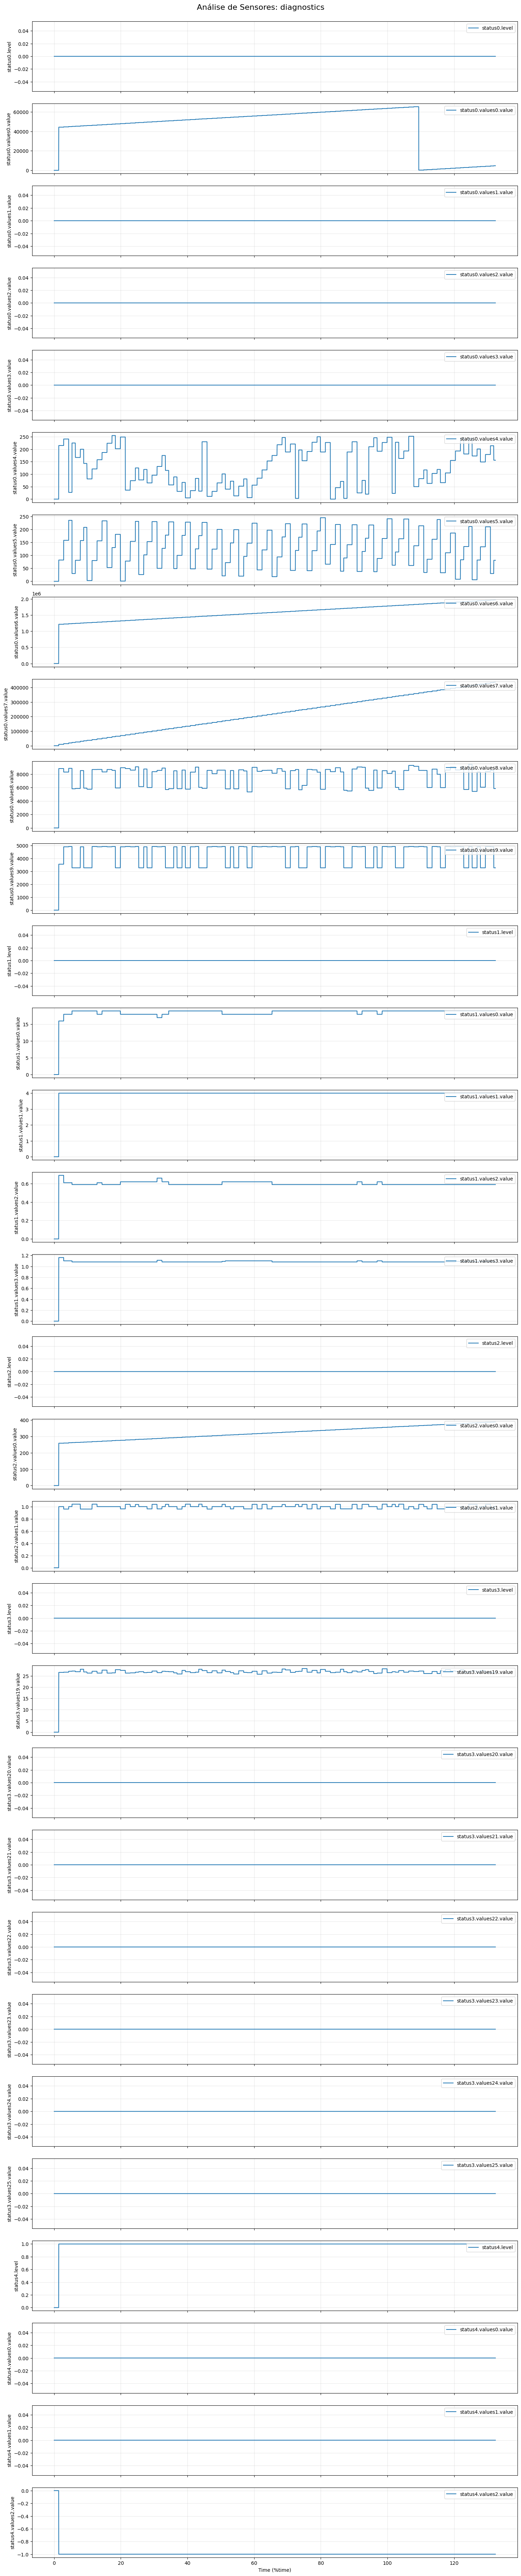

Plotando 1 colunas de: failure_status-engines


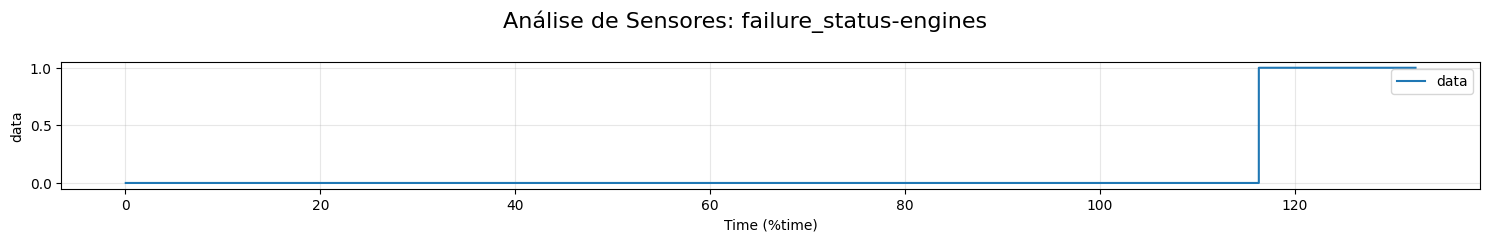

Plotando 3 colunas de: mavctrl-path_dev


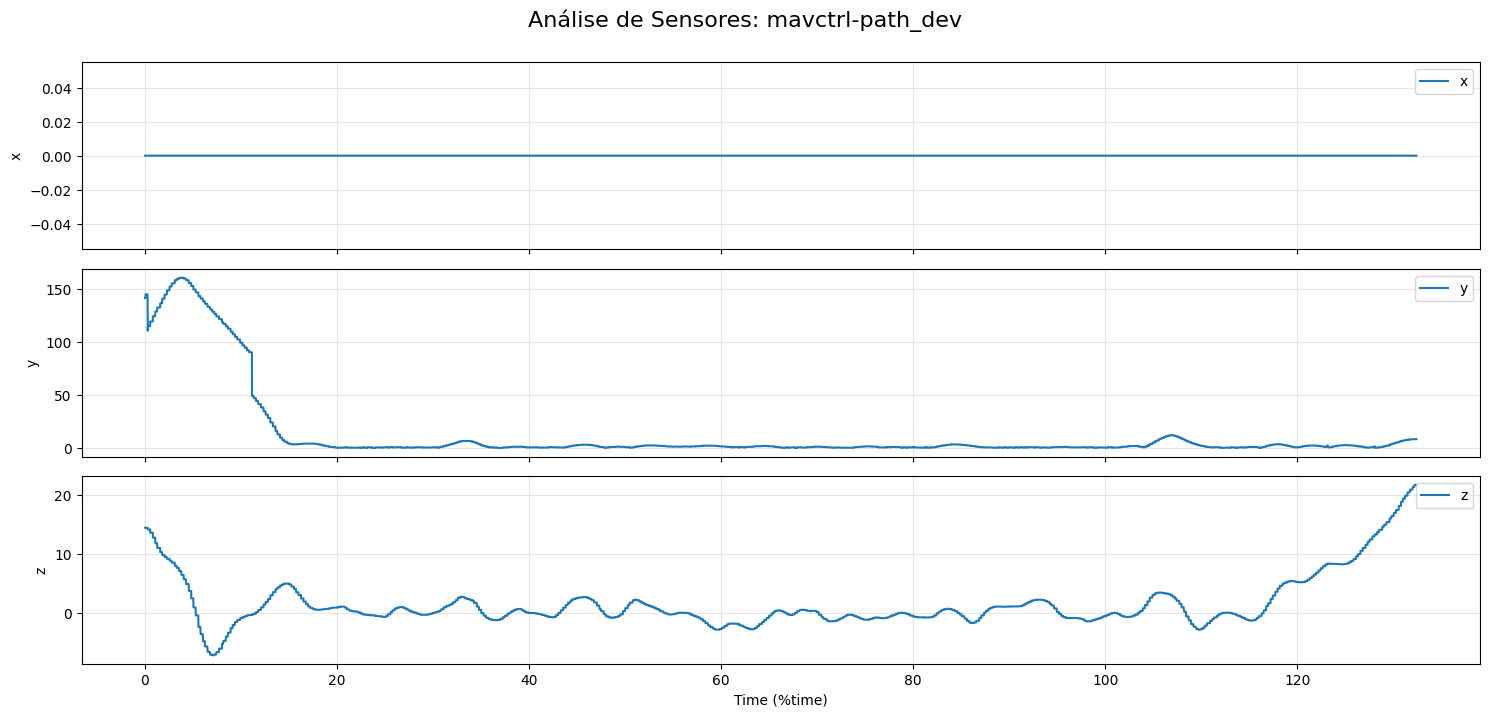

Plotando 7 colunas de: mavlink-from


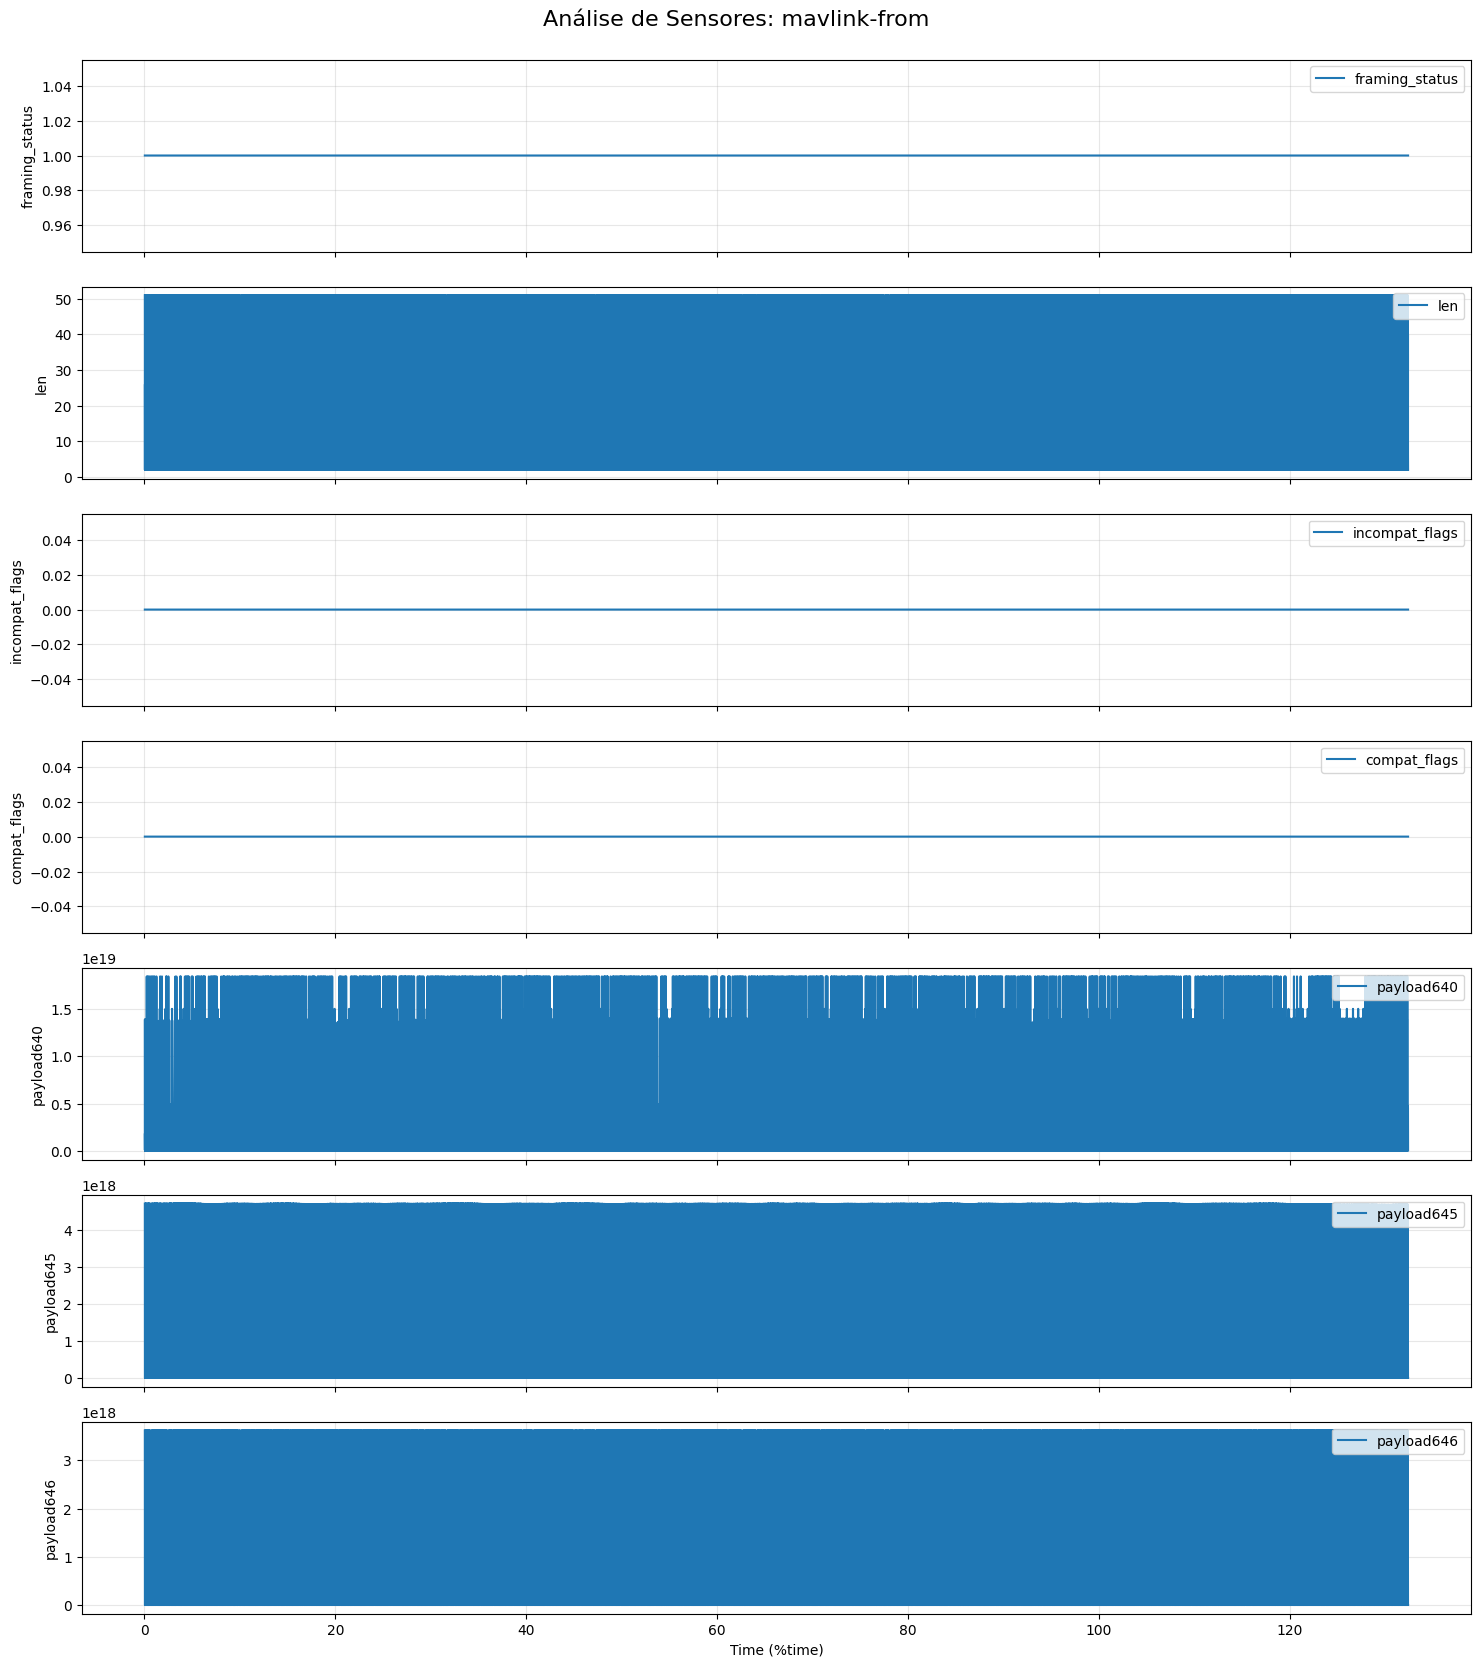

In [10]:
interessantes = ['diagnostics', 'failure_status-engines', 'mavctrl-path_dev', 'mavlink-from']
for p in interessantes:
    plot_flight_data_by_source(merged_df, p)

## Fontes que ainda restam explorar no merge:

 - mavros-global_position-compass_hdg
 - mavros-global_position-global
 - mavros-global_position-local
 - mavros-global_position-raw-fix
 - mavros-global_position-raw-gps_vel
 - mavros-global_position-rel_alt
 - mavros-imu-atm_pressure
 - mavros-imu-data
 - mavros-imu-mag
 - mavros-imu-temperature
 - mavros-local_position-odom
 - mavros-local_position-pose
 - mavros-local_position-velocity
 - mavros-nav_info-errors
 - mavros-nav_info-pitch
 - mavros-nav_info-roll
 - mavros-nav_info-velocity
 - mavros-nav_info-yaw
 - mavros-rc-in
 - mavros-rc-out
 - mavros-setpoint_raw-local
 - mavros-setpoint_raw-target_global
 - mavros-state
 - mavros-time_reference
 - mavros-vfr_hud
 - mavros-wind_estimation

Plotando 1 colunas de: mavros-global_position-compass_hdg


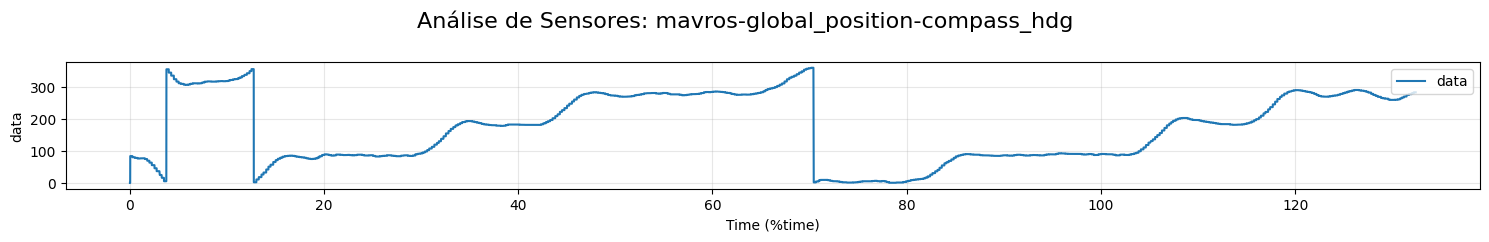

Plotando 5 colunas de: mavros-global_position-global


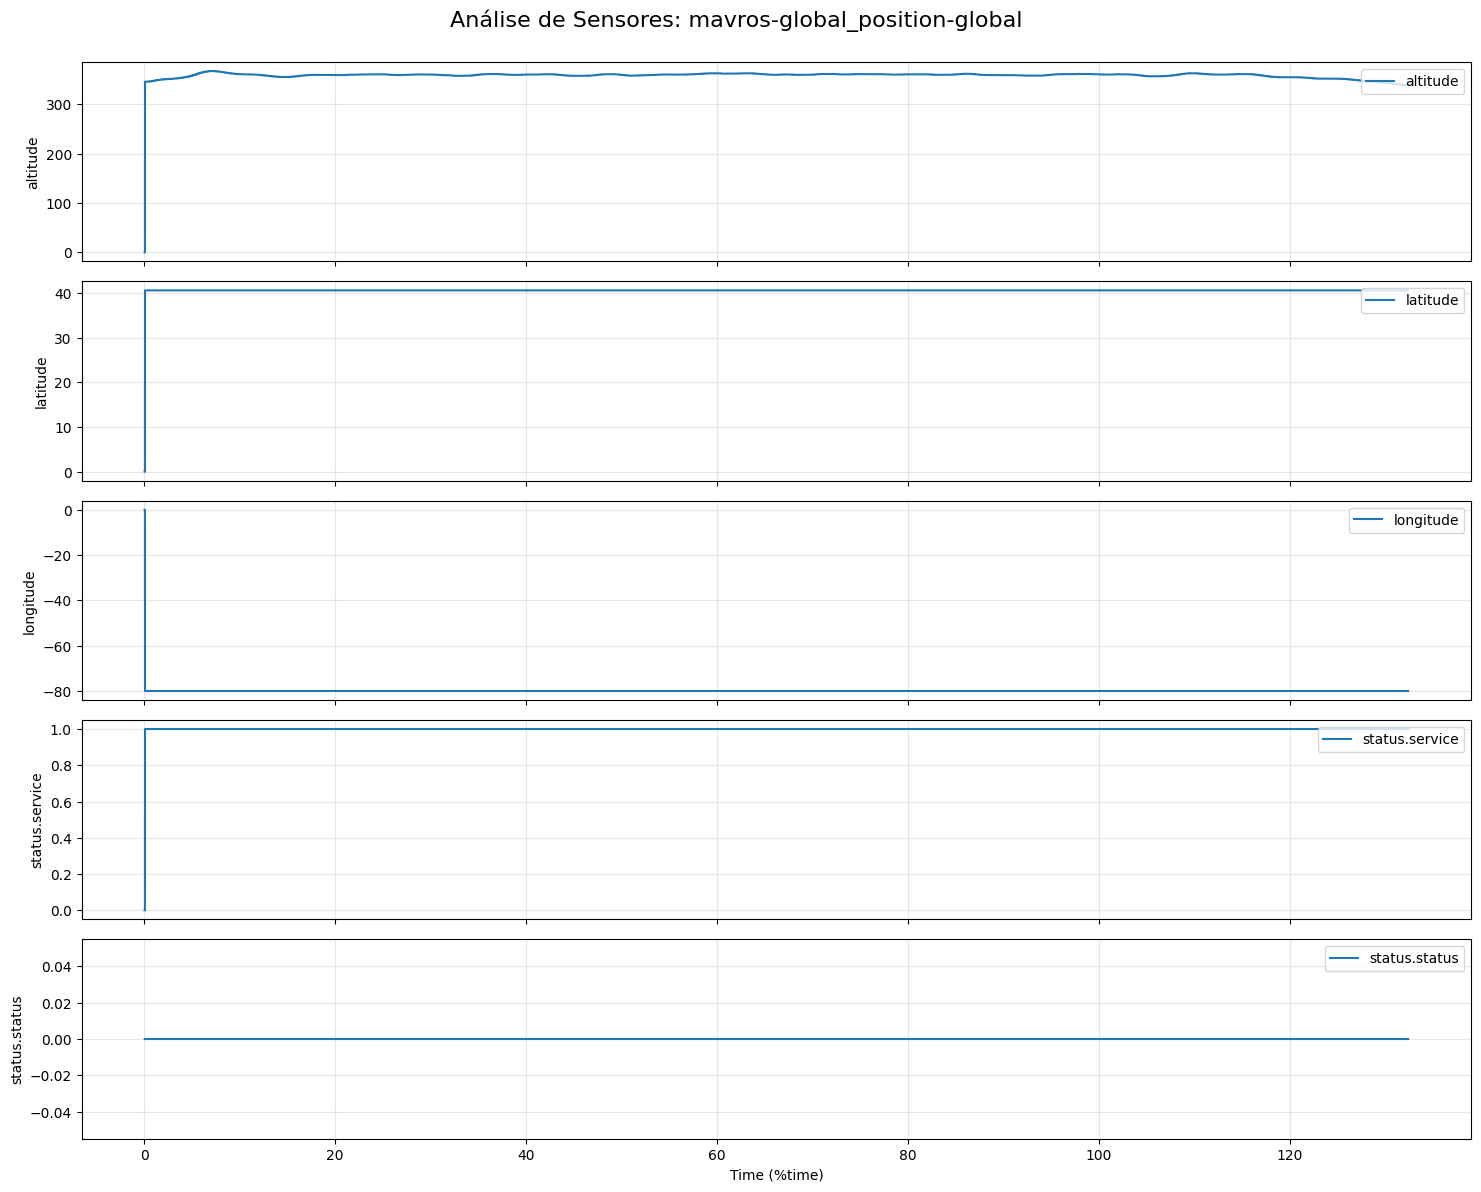

Plotando 13 colunas de: mavros-global_position-local


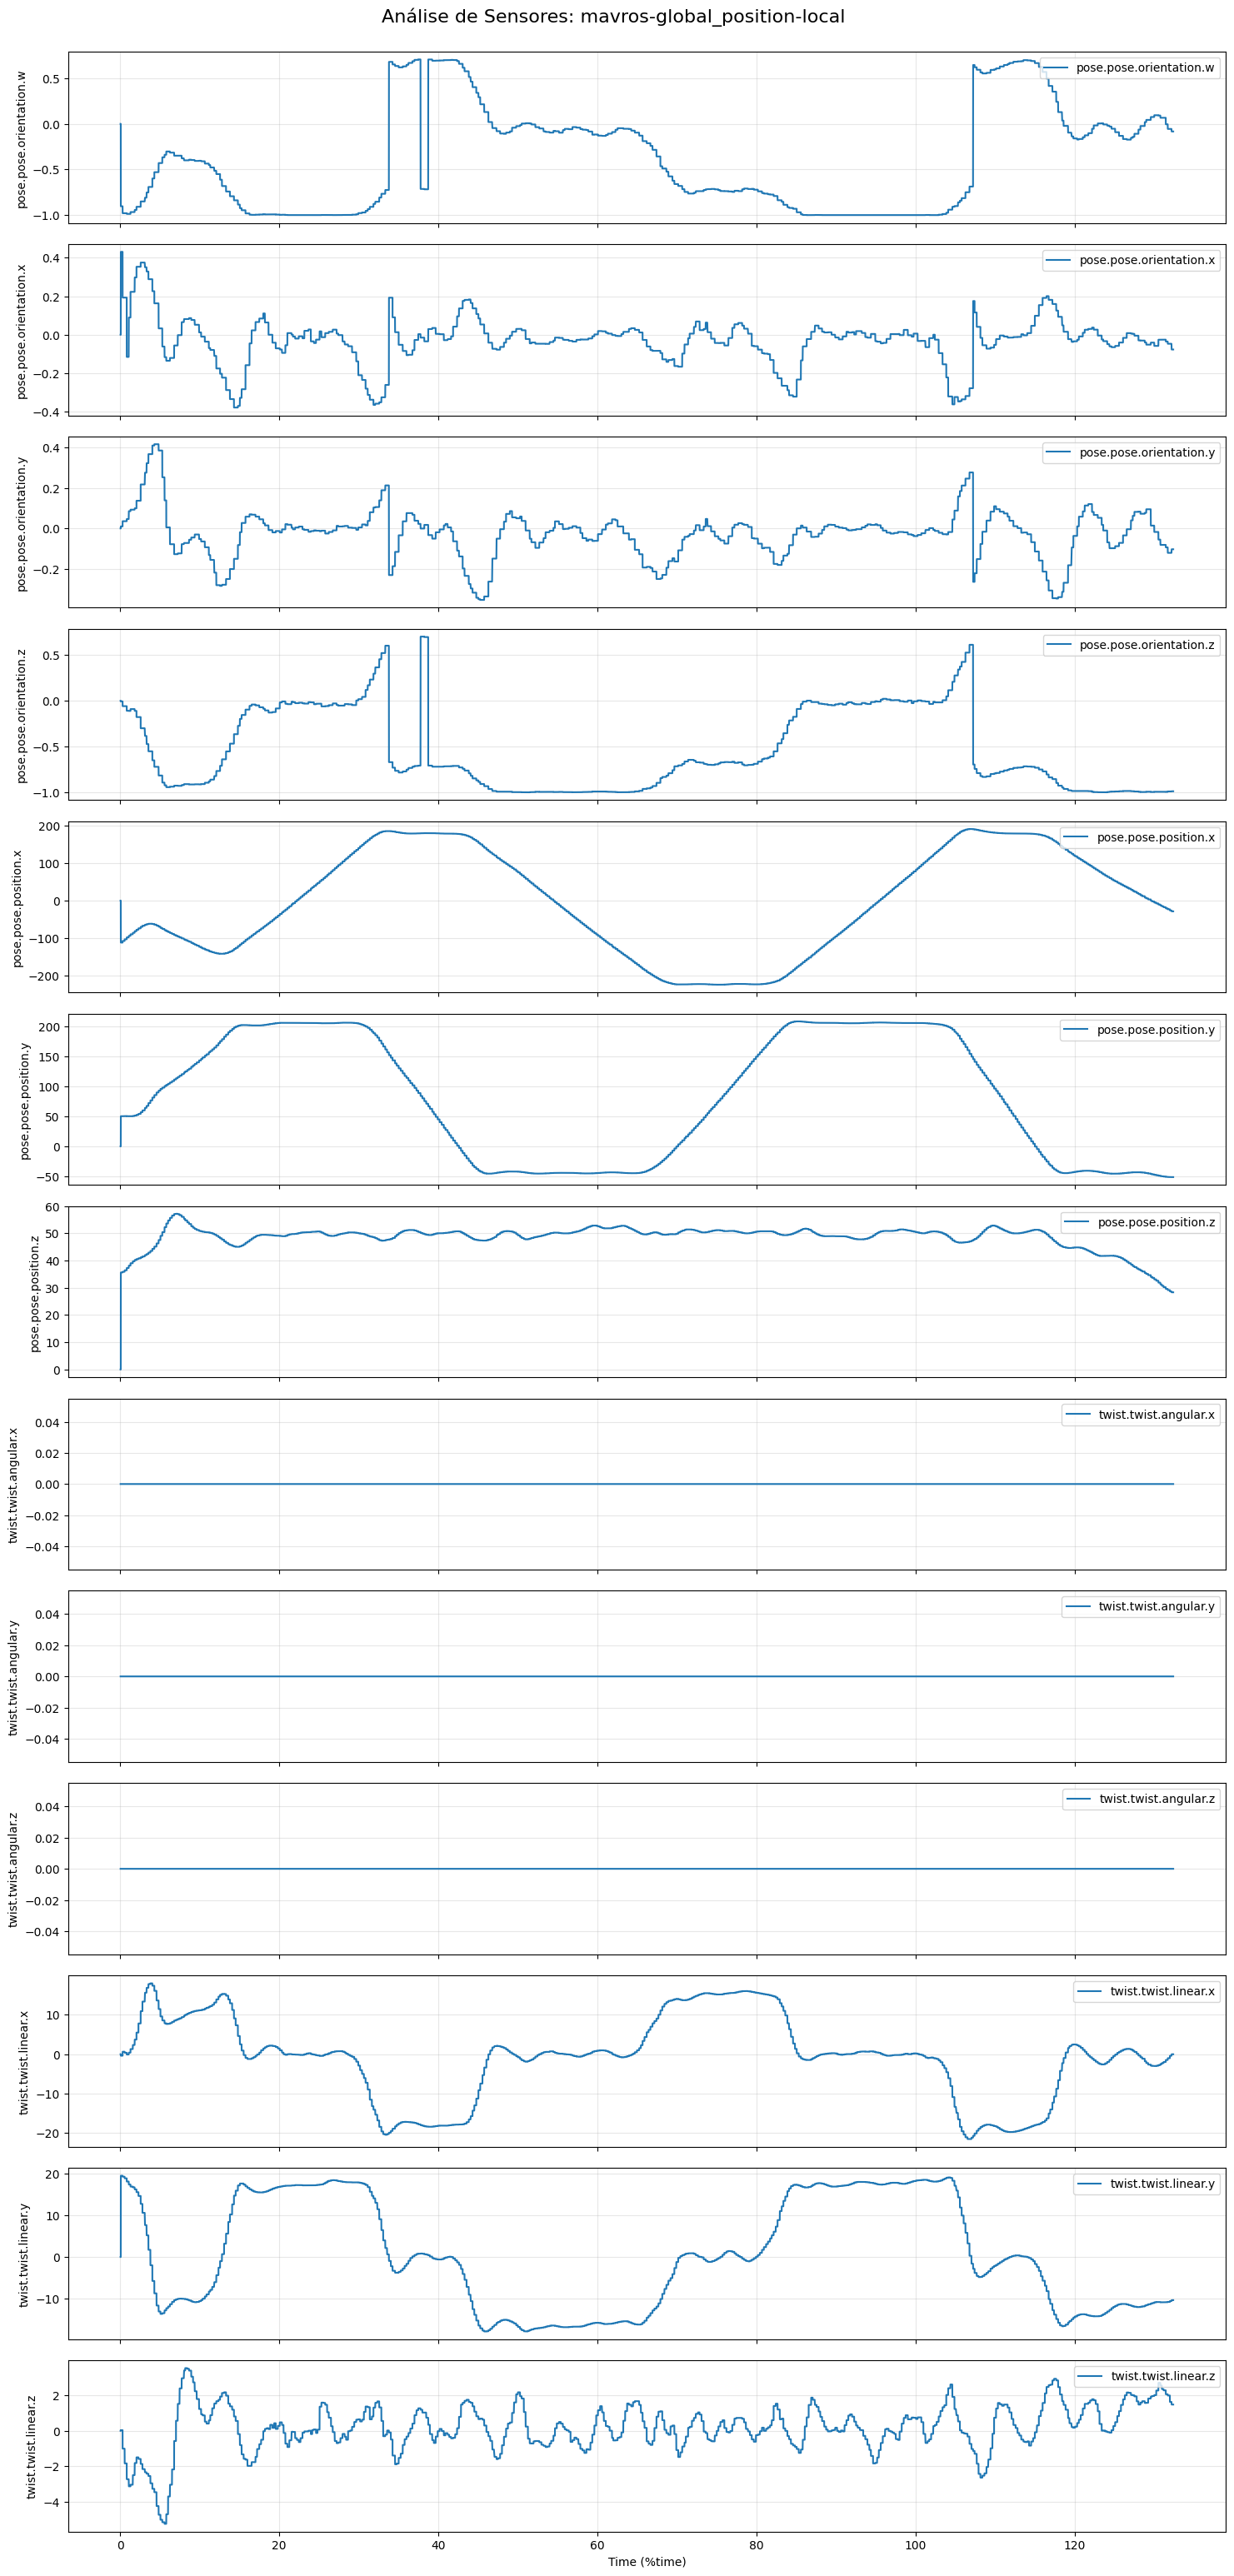

Plotando 5 colunas de: mavros-global_position-raw-fix


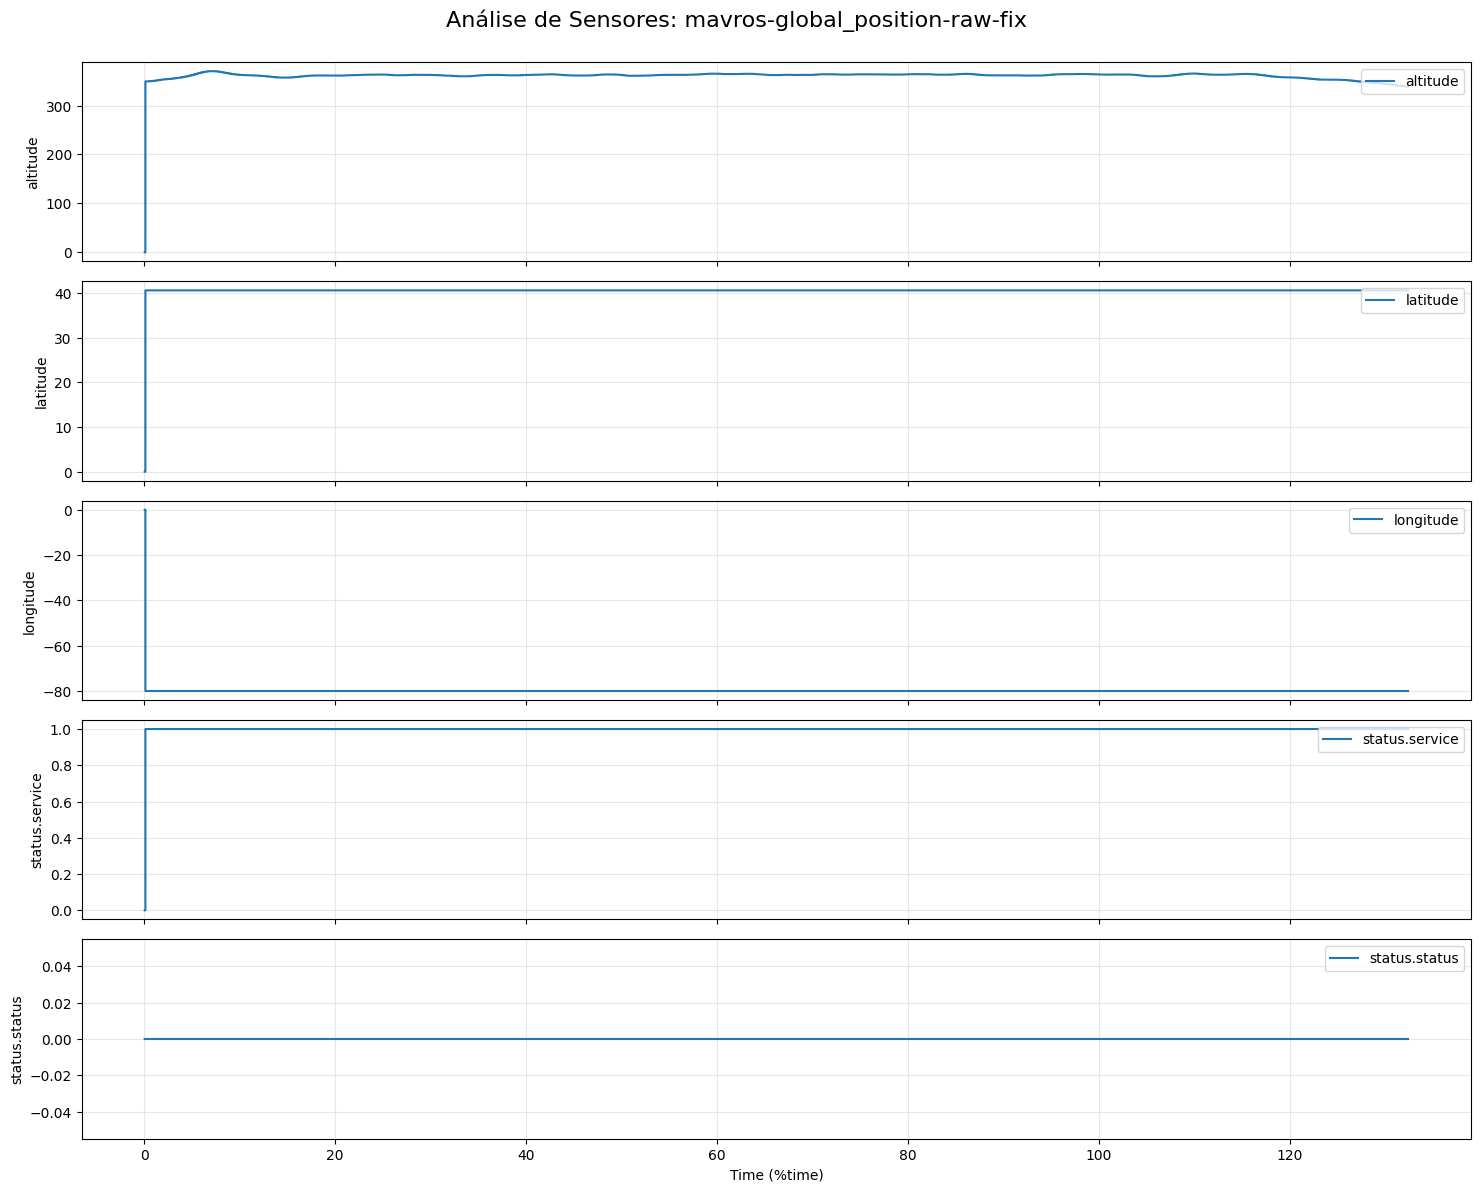

In [11]:
interessantes = ['mavros-global_position-compass_hdg', 'mavros-global_position-global', 'mavros-global_position-local', 'mavros-global_position-raw-fix']
for p in interessantes:
    plot_flight_data_by_source(merged_df, p)